# FACE DETECTION USING AZURE API KEY AND ENDPOINT

Analyzing Image 1...
{
    "faces": [
        {
            "faceRectangle": {
                "left": 234,
                "top": 134,
                "width": 97,
                "height": 97
            }
        }
    ],
    "requestId": "66e1799c-57f9-4009-996e-347e2e30d201",
    "metadata": {
        "height": 417,
        "width": 564,
        "format": "Png"
    },
    "modelVersion": "2021-05-01"
}


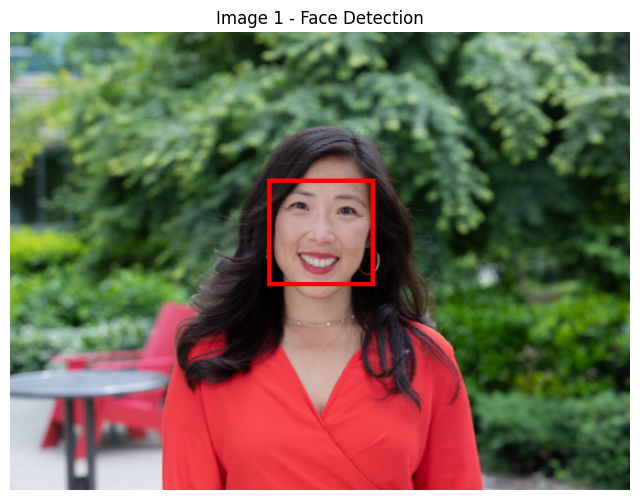

Analyzing Image 2...
{
    "faces": [
        {
            "faceRectangle": {
                "left": 234,
                "top": 134,
                "width": 97,
                "height": 97
            }
        }
    ],
    "requestId": "bdb359c0-c63b-4d0f-9c16-494a3efcb16d",
    "metadata": {
        "height": 417,
        "width": 564,
        "format": "Png"
    },
    "modelVersion": "2021-05-01"
}


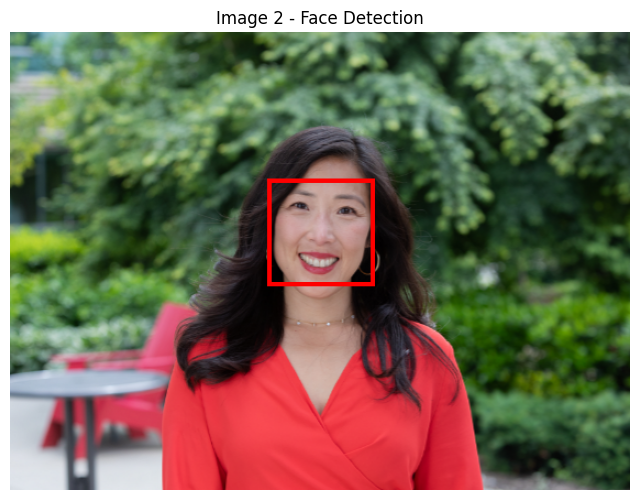

In [17]:
import requests
import json
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# ==============================
# Azure Credentials
# ==============================
SUBSCRIPTION_KEY = "API"
ENDPOINT = "https://myversion.cognitiveservices.azure.com/"

# ==============================
# Image paths
# ==============================
image1_path = "image.png"
image2_path = "image.png"

# ==============================
# API URL
# ==============================
analyze_url = ENDPOINT + "vision/v3.2/analyze?visualFeatures=Faces"

headers = {
    "Ocp-Apim-Subscription-Key": SUBSCRIPTION_KEY,
    "Content-Type": "application/octet-stream"
}


def detect_faces(image_path):
    with open(image_path, "rb") as image_file:
        image_data = image_file.read()

    response = requests.post(
        analyze_url,
        headers=headers,
        data=image_data
    )

    response.raise_for_status()
    return response.json()


def draw_bounding_boxes(image_path, result):
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)

    faces = result.get("faces", [])

    for face in faces:
        rect = face["faceRectangle"]

        left = rect["left"]
        top = rect["top"]
        width = rect["width"]
        height = rect["height"]

        right = left + width
        bottom = top + height

        # Draw rectangle
        draw.rectangle(
            [(left, top), (right, bottom)],
            outline="red",
            width=4
        )

    return image


def show_image(image, title):
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()


# ==============================
# Process Image 1
# ==============================
print("Analyzing Image 1...")
result1 = detect_faces(image1_path)

print(json.dumps(result1, indent=4))

boxed_image1 = draw_bounding_boxes(image1_path, result1)
show_image(boxed_image1, "Image 1 - Face Detection")


# ==============================
# Process Image 2
# ==============================
print("Analyzing Image 2...")
result2 = detect_faces(image2_path)

print(json.dumps(result2, indent=4))

boxed_image2 = draw_bounding_boxes(image2_path, result2)
show_image(boxed_image2, "Image 2 - Face Detection")